In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df=pd.read_csv(r"D:\Wholesale customers data.csv")
print(df)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  
..          ...

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
df.shape

(440, 8)

# Data cleaning

In [7]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Graph

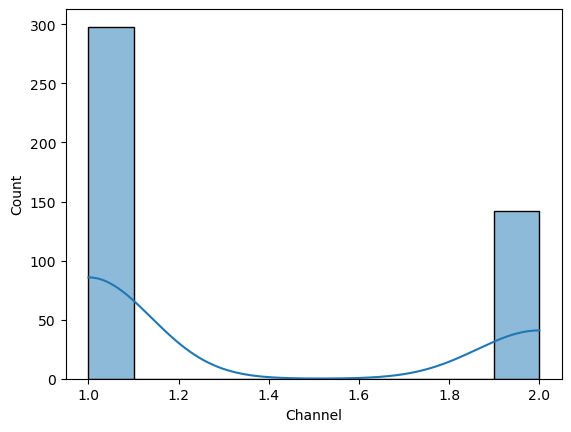

In [11]:
import seaborn as sns
sns.histplot(df["Channel"],kde=True)
plt.show()

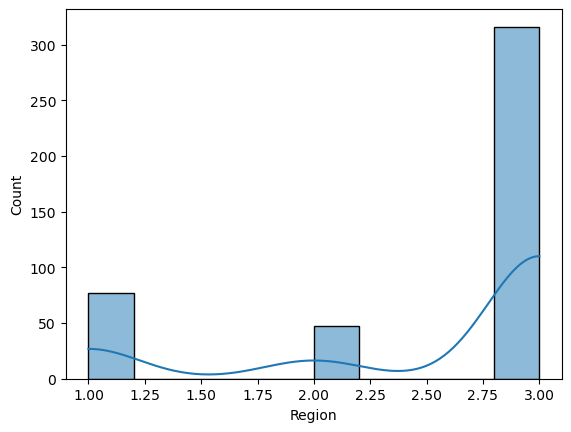

In [12]:
sns.histplot(df["Region"],kde=True)
plt.show()

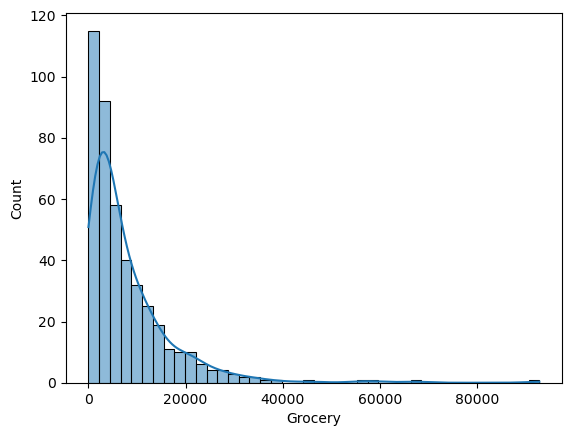

In [13]:
sns.histplot(df["Grocery"],kde=True)
plt.show()

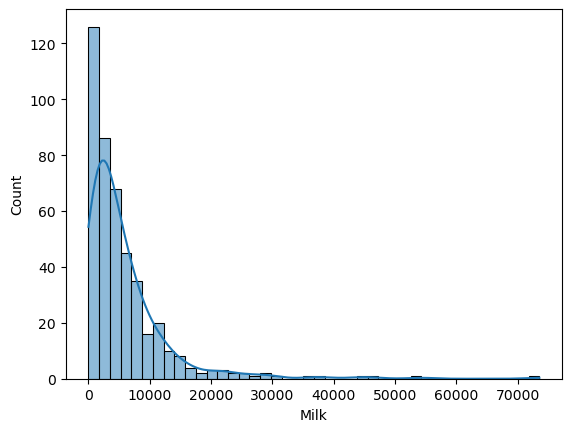

In [14]:
sns.histplot(df["Milk"],kde=True)
plt.show()

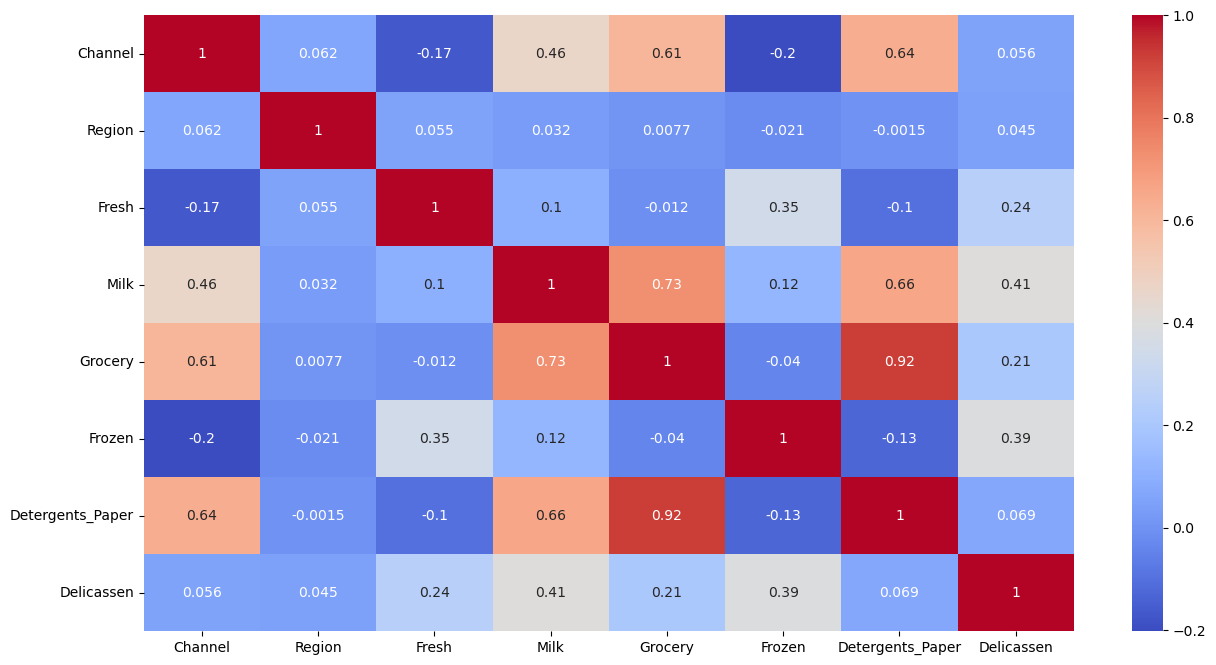

In [15]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [16]:
X=df.drop(["Channel","Region"],axis=1)

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
X_scaled = scaler.fit_transform(X)

# Train k_Means Model

In [22]:
from sklearn.cluster import KMeans

In [23]:
c=[]

In [24]:
for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42,n_init=10)
    model.fit(X_scaled)
    c.append(model.inertia_)

D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

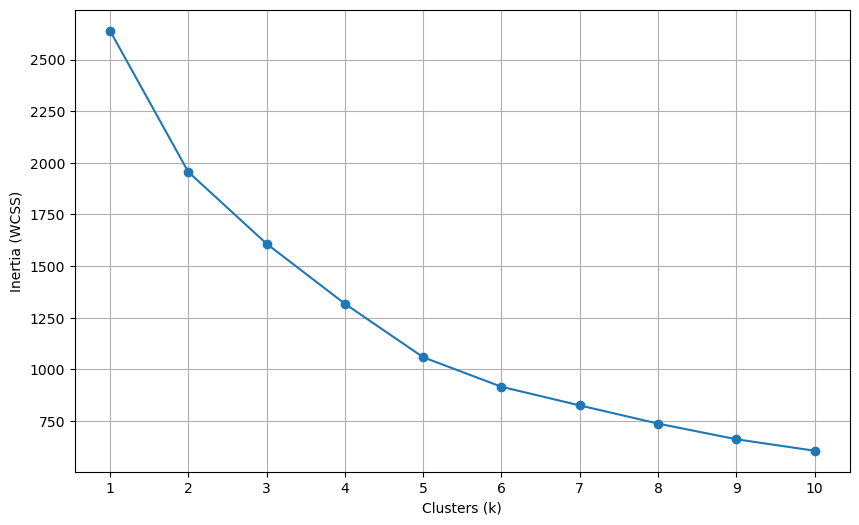

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), c, marker="o")
plt.xlabel("Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [26]:
model=KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10,
)

In [27]:
cluster=model.fit_predict(X_scaled)

D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [28]:
df["cluster"]=cluster

In [29]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,3
2,2,3,6353,8808,7684,2405,3516,7844,3
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


# Cluster Distribution

In [30]:
df["cluster"].value_counts()

cluster
0    270
3     96
2     63
1     10
4      1
Name: count, dtype: int64

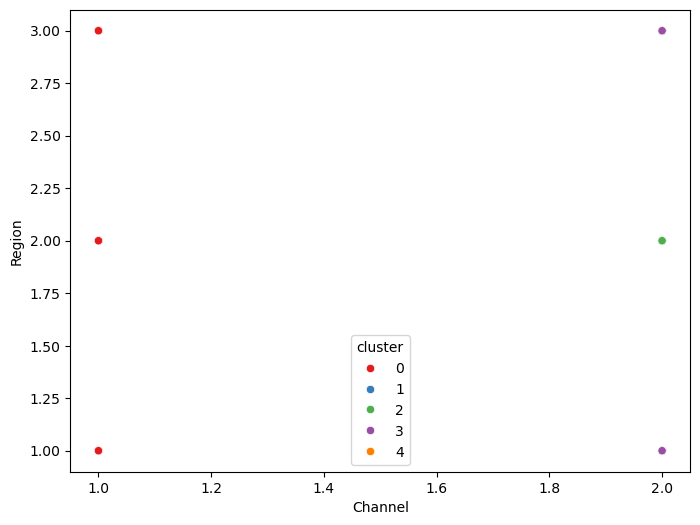

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Channel",y="Region",hue='cluster',palette='Set1',data=df
)
plt.show()

In [35]:
df.groupby("cluster").mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,,,
0,1.137037,2.518519,9092.155556,2967.759259,3807.411111,2271.759259,989.814815,978.962963
1,2.000000,2.500000,15964.900000,34708.500000,48536.900000,3054.600000,24875.200000,2942.800000
2,1.126984,2.682540,32957.984127,4997.349206,5884.761905,8422.841270,954.603175,2462.968254
3,1.906250,2.520833,5754.166667,10866.604167,16607.104167,1464.125000,7202.875000,1813.385417
4,1.000000,3.000000,36847.000000,43950.000000,20170.000000,36534.000000,239.000000,47943.000000


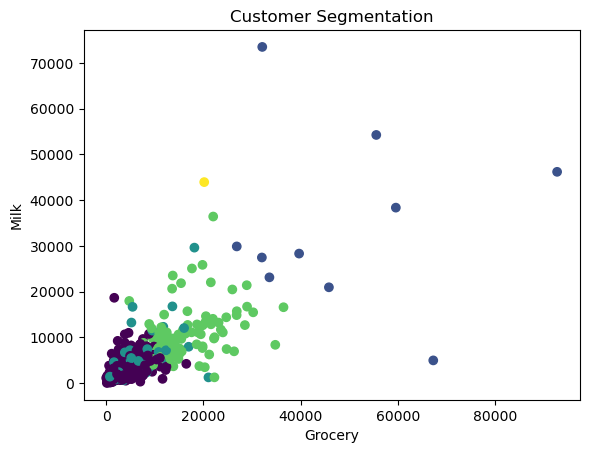

In [38]:
plt.scatter(df["Grocery"],df["Milk"],c=df["cluster"])
plt.xlabel("Grocery")
plt.ylabel("Milk")
plt.title("Customer Segmentation")
plt.show()